In [1]:
import glob
import json
import os
import math

from dotenv import load_dotenv

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
images_folder = "/mnt/h/Pronghorn Vertical Imagery/2024/PR529"
image_files = sorted(glob.glob(os.path.join(images_folder, f"*.[jJ][pP][gG]")))
print(f"{len(image_files)} files found.")

model_name = "03-24-2025-11-46-27"
# The folder where outputs from the inference notebook are stored
model_output_folder = os.path.join("/home/koger/pronghorn-processing", model_name)

948 files found.


## Load model predictions

In [3]:
predictions = []
for image_file in image_files:
    image_name = os.path.splitext(os.path.basename(image_file))[0]
    # Get corresponding box file for image
    box_file = os.path.join(model_output_folder, f"{image_name}_boxes.npy")
    if not os.path.exists(box_file):
        continue
    else:
        boxes = np.load(box_file)
    # Get corresponding score file for image
    score_file = os.path.join(model_output_folder, f"{image_name}_scores.npy")
    if not os.path.exists(score_file):
        print(f"{image_name} missing score file.")
        scores = None
    else:
        scores = np.load(score_file)
    # Get corresponding object class file for image
    label_file = os.path.join(model_output_folder, f"{image_name}_labels.npy")
    if not os.path.exists(label_file):
        print(f"{image_name} missing labels file.")
        labels = None
    else:
        labels = np.load(label_file)
    image_info = {"image_file": image_file,
                  "boxes": boxes,
                  "scores": scores,
                  "labels": labels
                 }
    predictions.append(image_info)
    

In [4]:
len(predictions)

948

## Calculated highest confidence pronghorn in each image

In [5]:
pronghorn_class = 2
count = 0
for pred in predictions:
    if len(pred['labels']) == 0:
        pred['max_pronghorn_score'] = -1
        continue
    is_pronghorn = pred['labels'] == pronghorn_class
    if not np.any(is_pronghorn):
        pred['max_pronghorn_score'] = -1
        continue
    max_score = np.max(pred['scores'][is_pronghorn])
    pred['max_pronghorn_score'] = max_score
    if max_score > .99:
        count += 1
print(f"{count} images with pronghorn above min confidence score." )

# Sort images based on max pronghorn score
predictions = sorted(predictions, key=lambda x: x['max_pronghorn_score'], reverse=True)

69 images with pronghorn above min confidence score.


## Visualize most confident predictions

In [6]:
def is_in_training_set(image_name, training_names):
    """ Check is image name is origin of one of the training images. 
    
    Args:
        image_name: name of target image with extension removed
        training_names: list of all image names in the training set
        
    Returns true is image_name is origin of one of the training images.
    """
    for training_name in training_names:
        if image_name in training_name:
            return True
    return False

min_score = .5

min_rank = 0
max_rank = 10

save_folder = f"/mnt/c/Users/benko/Dropbox/UWyo/pronghorn-census/outputs-5-632/{min_rank}-{max_rank}-{min_score:0.01f}"
os.makedirs(save_folder, exist_ok=True)

draw_box = True
crop_buffer = 100

for pred_num in range(min_rank, max_rank):
    pred = predictions[pred_num]
    image_name = os.path.splitext(os.path.basename(pred['image_file']))[0]
    image = plt.imread(pred['image_file']).copy()
    
    num_drawn = 0

    crops = []
    scores = []
    
    for box, score, label in zip(pred['boxes'], pred['scores'], pred['labels']):
        if (score < min_score) or (label != pronghorn_class):
            continue
        ymin = np.max([box[1] - crop_buffer, 0])
        ymax = np.min([box[3] + crop_buffer, image.shape[0]])
        xmin = np.max([box[0] - crop_buffer, 0])
        xmax = np.min([box[2] + crop_buffer, image.shape[1]])
        crops.append(image[ymin:ymax, xmin:xmax].copy())
        scores.append(score)
        if draw_box:
            cv2.rectangle(image, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 3)

    crop_size = 2
    max_cols = 6
    max_crops = 36

    crops = crops[:max_crops]
    scores = scores[:max_crops]
    if len(crops) <= max_cols:
        cols = len(crops)
        rows = 1
    else:
        cols = max_cols
        rows = math.ceil(len(crops) / max_cols)
    fig, axs = plt.subplots(rows, cols, figsize=(cols * crop_size, rows * crop_size))

    # if len(crops) == 1:
    #     axs = [axs]
    for ax, crop, score in zip(fig.axes[:len(crops)], crops, scores):
        ax.imshow(crop)
        ax.set_title(f"score: {score:.3f}")
        ax.set_axis_off() 

    fname = os.path.join(save_folder, f"rank-{pred_num+1:03d}-{image_name}")
    fig.savefig(f"{fname}_crops.jpg", dpi=300, bbox_inches='tight')
    plt.close(fig)
              
    plt.figure(figsize=(15,15))
    plt.imshow(image)
    plt.axis('off')
    plt.savefig(f"{fname}_whole_image.jpg", dpi=300, bbox_inches='tight')
    plt.close()
    

### Examine confidence scores for all predictions

In [7]:
pronghorn_class = 2

ph_confidence = []

count = 0
for pred in predictions:
    if len(pred['labels']) == 0:
        pred['max_pronghorn_score'] = -1
        continue
    is_pronghorn = pred['labels'] == pronghorn_class
    if not np.any(is_pronghorn):
        pred['max_pronghorn_score'] = -1
        continue
    ph_confidence.append(pred['scores'][is_pronghorn])
ph_confidence = np.concatenate(ph_confidence)

7534


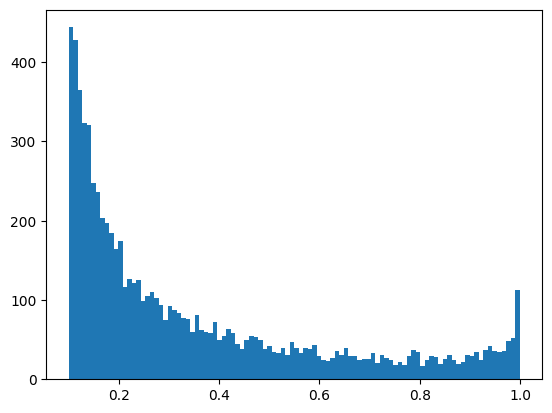

In [8]:
score_thresh = .1
plt.hist(ph_confidence[ph_confidence>score_thresh], bins=100)
print(np.sum(ph_confidence>score_thresh))